In [39]:
from utility import *
from matplotlib import cm
 
supersize=9
ncell = supersize**3
natoms = ncell * 5

temp_list = [300,600,700,800,820,900,1000]
arr_F100 = np.load('FES_yz_all_temp.npy')
arr_F110 = np.load('FES_110_all_temp.npy')

nbins = 101
sample_time = 8
xlim = 0.06 * e2uC / Atcm**2
ylim = 0.06 * e2uC / Atcm**2

####### Load FES data on cross sections
arr_F100 = arr_F100.reshape(len(temp_list),-1,nbins,nbins)   # Pz=0 plane
arr_F110 = arr_F110.reshape(len(temp_list),-1,nbins,nbins)   # Px=Py plane

####### PREPARE grids
gridx = np.arange(nbins)/nbins * xlim
gridy = np.arange(nbins)/nbins * ylim
X,Y = np.meshgrid(gridx, gridy)
vmin, vmax = 0, 18



# Check convergence of WT-MetaD at T=600K

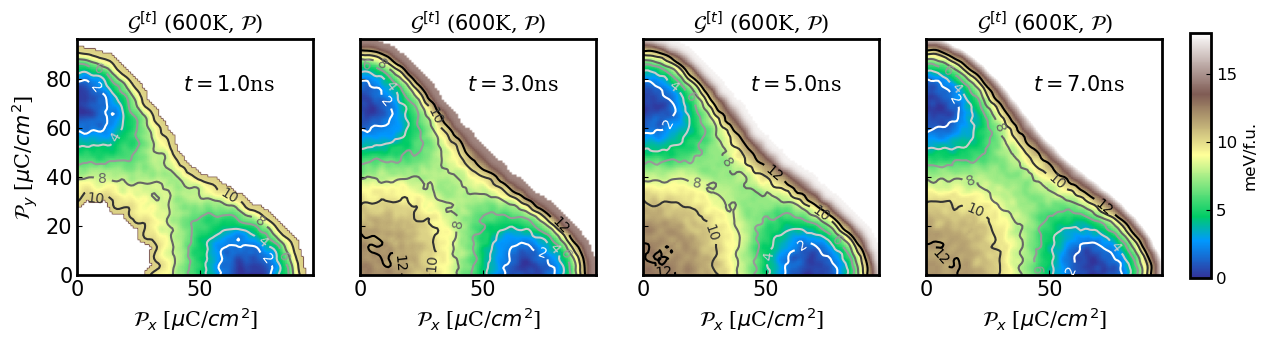

In [44]:
## Copy here the sampling frequency of WT-MetaD
pace=500
stride=4000
time_invertal=pace*stride*dt / 1000 #ns
##
temp= 600
F_list = arr_F100[1,:].copy()
F_list = [F-F.min() for F in F_list] ## shift to zero min for easier comparison
nf = 4
fig, ax  = plt.subplots(1, nf, figsize=(nf*3.5,3.5),sharey='all')
idx=0
title = ['a','b','c','d']
for fidx, F in enumerate(F_list):
    if fidx%2 == 1:
        continue
    F_explored = F.copy()
    Fmax = F_explored.max()
    F_explored[np.abs(F_explored - Fmax)<0.01] = F_explored[np.abs(F_explored - Fmax)<0.01]*0 + vmax ## mask unexplored region
    im=ax[idx].imshow(F_explored, cmap=cm.terrain, 
                      interpolation='antialiased', origin='lower', 
                      vmin=vmin, vmax=vmax, extent=(0,xlim,0,ylim))
    ax[idx].set_title(r'$\mathcal{{G}}^{{[t]}}$ (${}$K, $\mathcal{{P}}$)'.format(temp),
                        fontdict=text_font,loc='center')
    ax[idx].text(0.45, 0.85, r'$t={}$ns'.format( (fidx+1)*time_invertal),
                        transform=ax[idx].transAxes, fontdict=text_font, verticalalignment='top')
    ax[idx].set_xlabel(r'$\mathcal{P}_x$ [$\mu$C/$cm^2$]',fontdict=font)
    idx += 1
## Draw equipotential lines
levels = [2,4,6,8, 10, 12 ]
for idx in range(nf):
    CS = ax[idx].contour(X,Y, F_list[idx], linewidths=1.5,levels=levels, cmap='binary')
    ax[idx].clabel(CS, CS.levels, inline=True,  fontsize=10)
ax[0].set_ylabel(r'$\mathcal{P}_y$ [$\mu$C/$cm^2$]',fontdict=font)
# Shrink main figure to make room for colorbar
plt.subplots_adjust(right=0.9)

# Add single colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=12)
cbar.set_label('meV/f.u.', fontsize=12)
# fig.tight_layout()
fig.savefig('FES-{}K-convergence.png'.format(temp),dpi=300)


# PLOT Cross-sections of final free energy surface

## Pz=0 plane

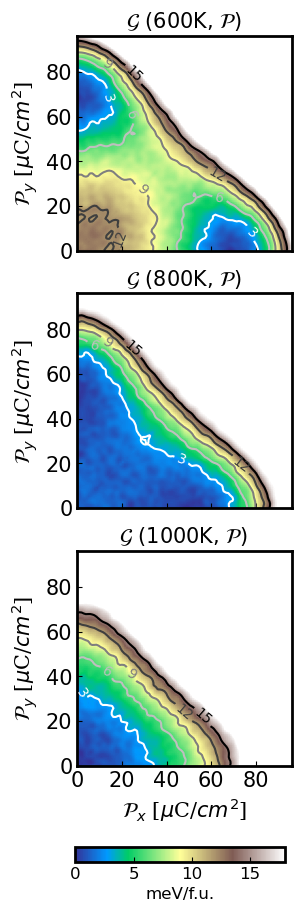

In [41]:
######## 
plot_temp = [600,800,1000]
F100_list = []
F110_list = []
for ii, temp in enumerate(temp_list):
    if temp in plot_temp:
        F100_list.append(arr_F100[ii,-1])
        F110_list.append(arr_F110[ii,-1])

nplots = len(plot_temp)
fig, ax  = plt.subplots(nplots,1, figsize=(3.5, nplots*3.2),sharex='all',sharey='all')

# Find global min/max for consistent color mapping

for idx, temp in enumerate(plot_temp):
    fes = F100_list[idx].transpose()
    fes -= fes.min()
    im = ax[idx].imshow(fes, cmap=cm.terrain, interpolation='antialiased', origin='lower', vmin=vmin, vmax=vmax,
        extent=(0,xlim,0,ylim))
    levels = [3,6,9,12, 15 ]
    CS = ax[idx].contour(X,Y, fes, linewidths=1.5,levels=levels, cmap='binary')
    ax[idx].clabel(CS, CS.levels, inline=True,  fontsize=10)
    ax[idx].set_title(r'$\mathcal{{G}}$ (${}$K, $\mathcal{{P}}$) '.format( temp),
                        fontsize=15,loc='center')
    # ax[idx].text(0.5, 0.9, 'Unexplored', transform=ax[idx].transAxes, fontsize=13, verticalalignment='top')

    ax[idx].set_ylabel(r'$\mathcal{P}_y$ [$\mu$C/$cm^2$]',fontdict=font)
    ax[idx].set_xticks([0,20,40,60,80])

# ax[0].text(0.02, 0.2, 'Under', transform=ax[0].transAxes, fontsize=13, verticalalignment='top')
# ax[0].text(0.02, 0.1, '-explored', transform=ax[0].transAxes, fontsize=13, verticalalignment='top')
ax[-1].set_xlabel(r'$\mathcal{P}_x$ [$\mu$C/$cm^2$]',fontdict=font)

# Shrink main figure to make room for colorbar
plt.subplots_adjust(bottom=0.12)

# Add single colorbar on the right
# cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.015])

cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label('meV/f.u.', fontsize=12)

# plt.tight_layout()
plt.savefig('FES-projected-XY.png', dpi=300, bbox_inches='tight')

# Px=Py plane

/tmp/ipykernel_1422844/615378912.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 350x960 with 4 Axes> than <Figure size 350x1050 with 4 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04, ticks=cbar.get_ticks())
/tmp/ipykernel_1422844/615378912.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 350x960 with 4 Axes> than <Figure size 350x1050 with 5 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04, ticks=cbar.get_ticks())
/tmp/ipykernel_1422844/615378912.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 350x960 with 4 Axes> than <Figure size 350x1050 with 6 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04, ticks=cbar.get_ticks())


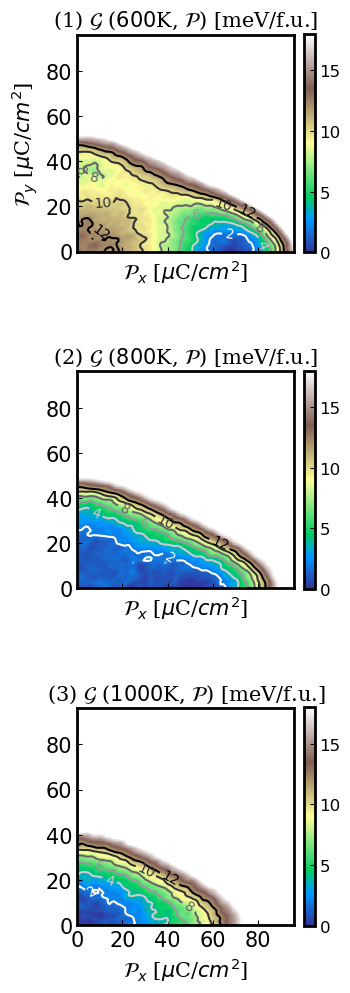

In [42]:
fig, ax  = plt.subplots(nplots, 1, figsize=(3.5, nplots*3.5),sharex='all',sharey='all')
for idx, temp in enumerate(plot_temp):
    fes = F110_list[idx].transpose()
    fes -= fes.min()
    ax[idx].imshow(fes, # cmap='RdGy', 
        cmap=cm.terrain, interpolation='antialiased', origin='lower', vmin=vmin, vmax=vmax,
        extent=(0,xlim,0,ylim))
    
    levels = [2,4,6,8, 10 , 12]
    CS = ax[idx].contour(X,Y, fes, linewidths=1.5,levels=levels, cmap='binary')
    ax[idx].clabel(CS, CS.levels, inline=True,  fontsize=10)
    # ax[idx].text(0.5, 0.9, 'Unexplored', transform=ax[idx].transAxes, fontsize=13, verticalalignment='top')
    ax[idx].set_title(r'({}) $\mathcal{{G}}$ (${}$K, $\mathcal{{P}}$) [meV/f.u.]'.format(idx+1, temp),
                        fontdict=text_font,loc='center')
    ax[idx].set_xlabel(r'$\mathcal{P}_x$ [$\mu$C/$cm^2$]',fontdict=font)
    ax[idx].set_xticks([0,20,40,60,80])
    cbar = plt.colorbar(im, ax=ax[idx], fraction=0.046, pad=0.04, ticks=cbar.get_ticks())
    cbar.ax.tick_params(labelsize=12)
ax[0].set_ylabel(r'$\mathcal{P}_y$ [$\mu$C/$cm^2$]',fontdict=font)
fig.tight_layout()
# plt.savefig('FES-projected-XYZ.png', dpi=300)
